In [132]:
import pandas as pd

# خواندن دیتاست (فایل csv)
data = pd.read_csv("diabetes.csv")

# نمایش چند سطر اول
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


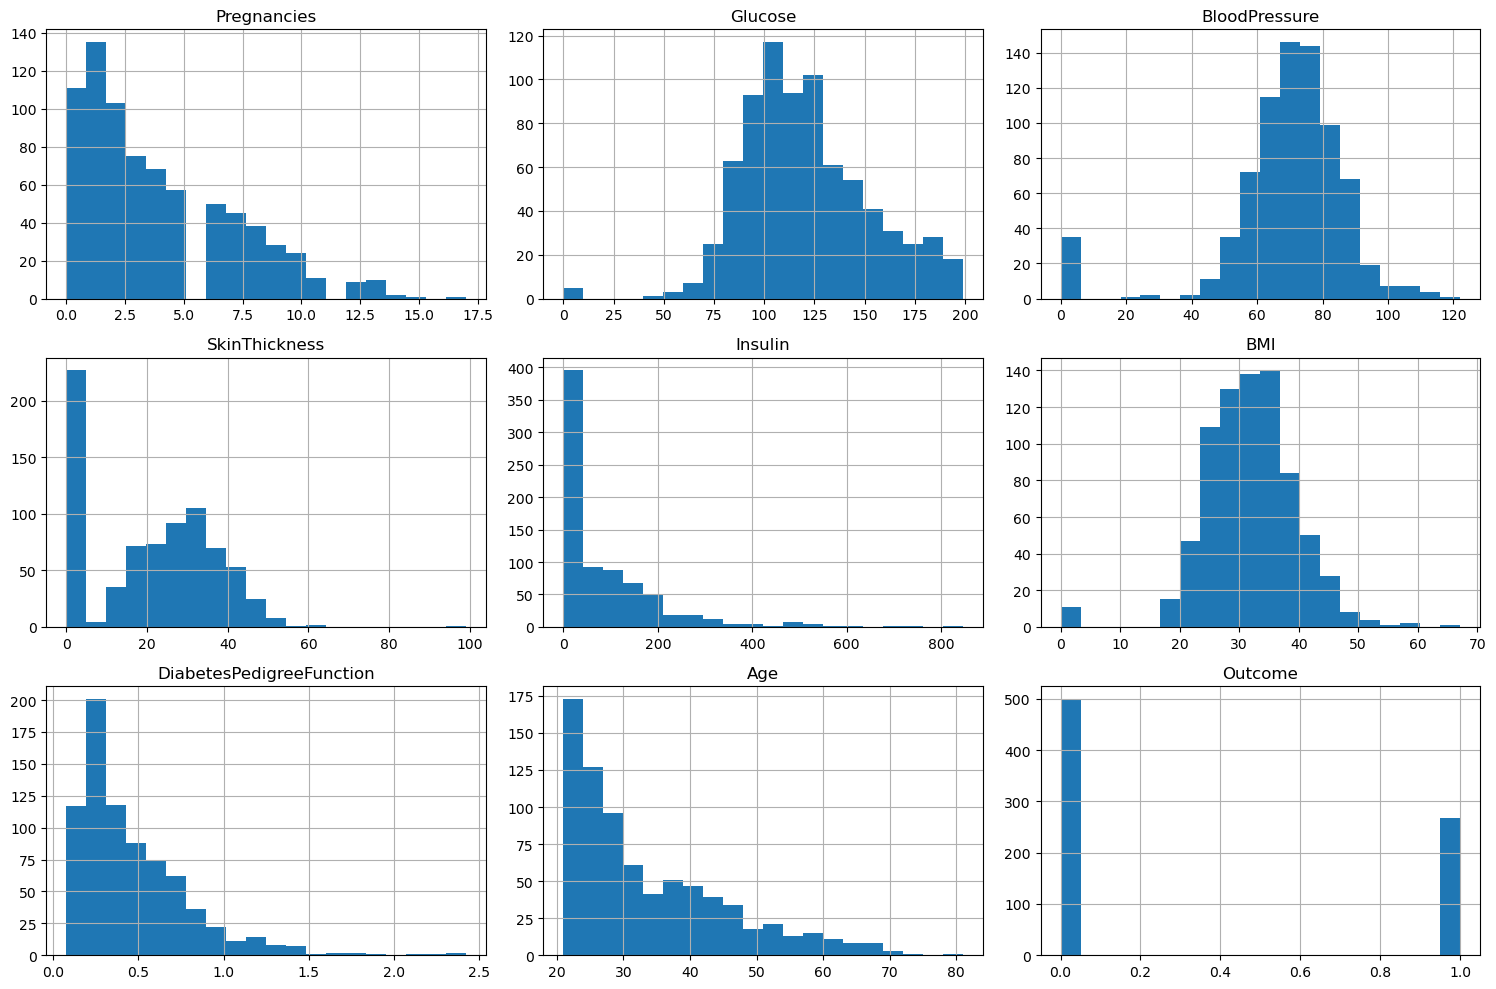

In [133]:
import matplotlib.pyplot as plt

data.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


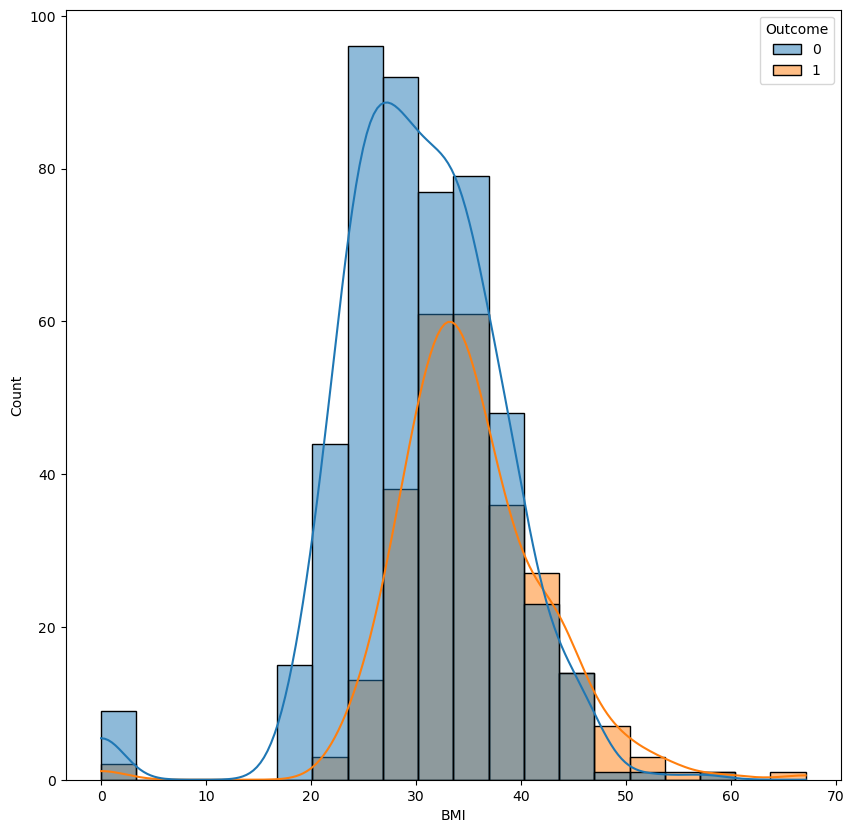

In [134]:
import seaborn as sns

plt.figure(figsize=(10,10))
sns.histplot(data=data, x="BMI", hue="Outcome", kde=True, bins=20)
plt.show()

/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/pydevcasts/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


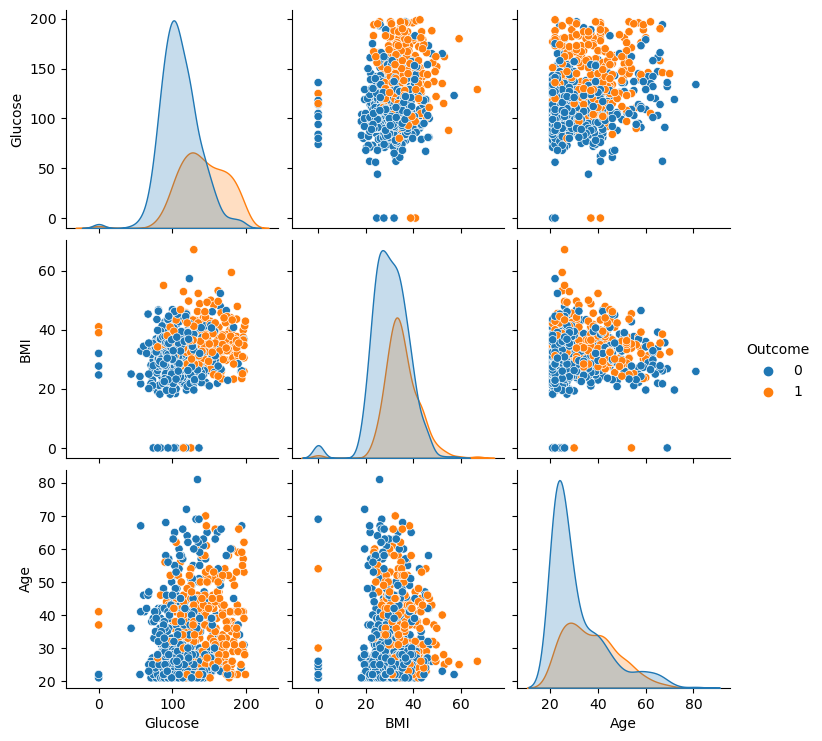

In [135]:
sns.pairplot(data[["Glucose", "BMI", "Age", "Outcome"]], hue="Outcome")
plt.show()

In [136]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [137]:
from sklearn.model_selection import train_test_split

# Separate features and target label
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Split data into training and testing sets (70% train, 30% test)
# Use stratify=y to maintain the same proportion of classes in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [139]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=15)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [140]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7705627705627706
Confusion Matrix:
 [[134  16]
 [ 37  44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83       150
           1       0.73      0.54      0.62        81

    accuracy                           0.77       231
   macro avg       0.76      0.72      0.73       231
weighted avg       0.77      0.77      0.76       231



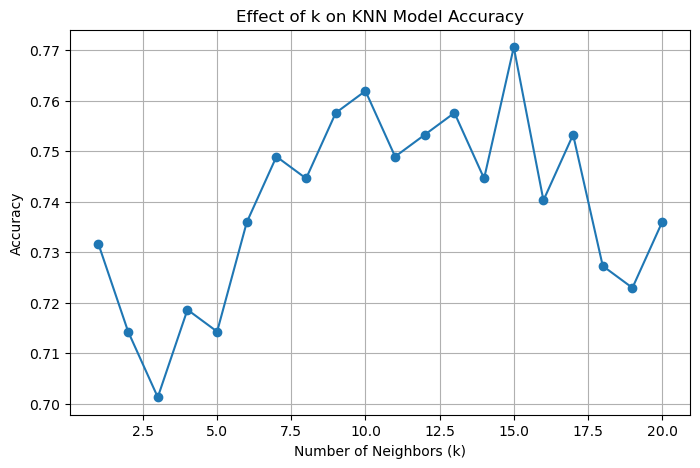

In [141]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

accuracies = []

# Test k values from 1 to 20
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Effect of k on KNN Model Accuracy")
plt.grid(True)
plt.show()

In [142]:
from sklearn.feature_selection import SelectKBest, chi2

# Apply SelectKBest with chi2 score function
selector = SelectKBest(score_func=chi2, k=5)
X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age'], dtype='object')


In [143]:
# Split new dataset with selected features
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X[selected_features], y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_fs)
X_test_fs = scaler.transform(X_test_fs)

# Train KNN with selected features
knn_fs = KNeighborsClassifier(n_neighbors=17)  # chosen from previous step
knn_fs.fit(X_train_fs, y_train_fs)
y_pred_fs = knn_fs.predict(X_test_fs)

# Evaluate
print("Accuracy with Feature Selection:", accuracy_score(y_test_fs, y_pred_fs))
print("Confusion Matrix:\n", confusion_matrix(y_test_fs, y_pred_fs))
print("Classification Report:\n", classification_report(y_test_fs, y_pred_fs))

Accuracy with Feature Selection: 0.7489177489177489
Confusion Matrix:
 [[129  21]
 [ 37  44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       150
           1       0.68      0.54      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



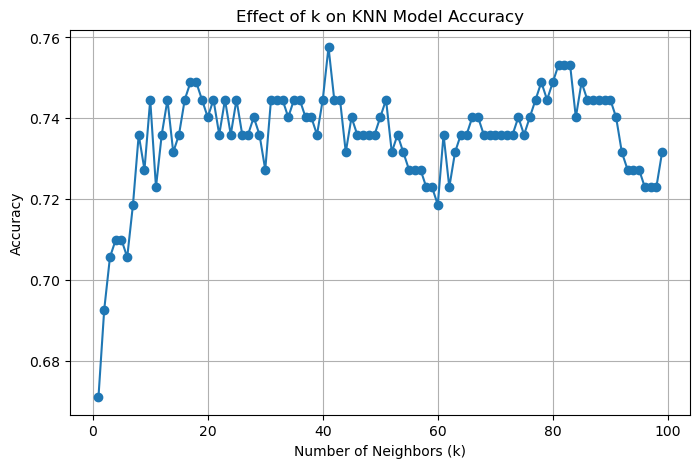

In [144]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

accuracies = []

# Test k values from 1 to 20
for k in range(1, 100):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_fs, y_train_fs)
    y_pred_fs = knn.predict(X_test_fs)
    acc = accuracy_score(y_test_fs, y_pred_fs)  # 🛠️ Fixed: use y_test_fs, not X_test_fs
    accuracies.append(acc)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 100), accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Effect of k on KNN Model Accuracy")
plt.grid(True)
plt.show()

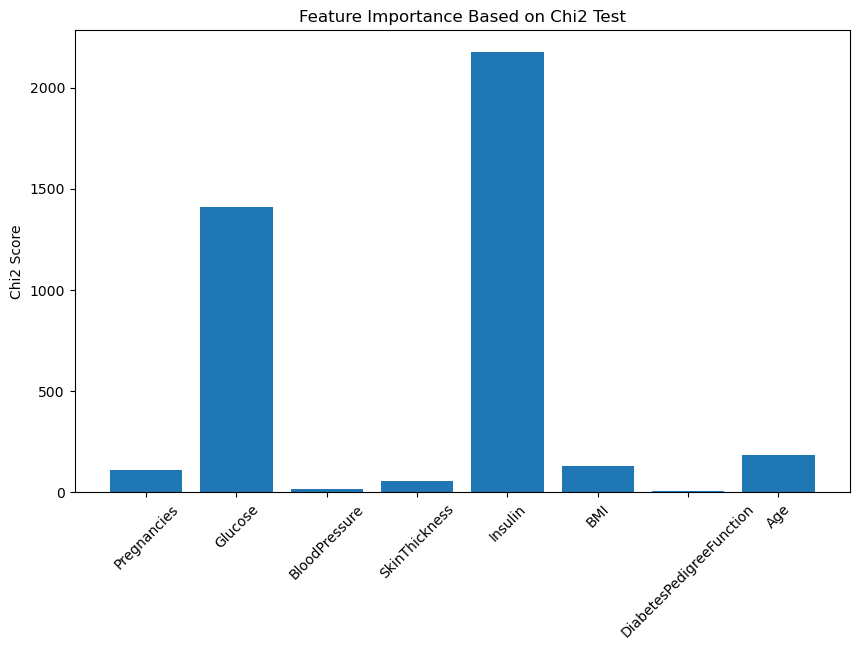

In [145]:
import numpy as np
import matplotlib.pyplot as plt

# Get scores from SelectKBest
scores = selector.scores_

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(X.columns, scores)
plt.xticks(rotation=45)
plt.ylabel("Chi2 Score")
plt.title("Feature Importance Based on Chi2 Test")
plt.show()

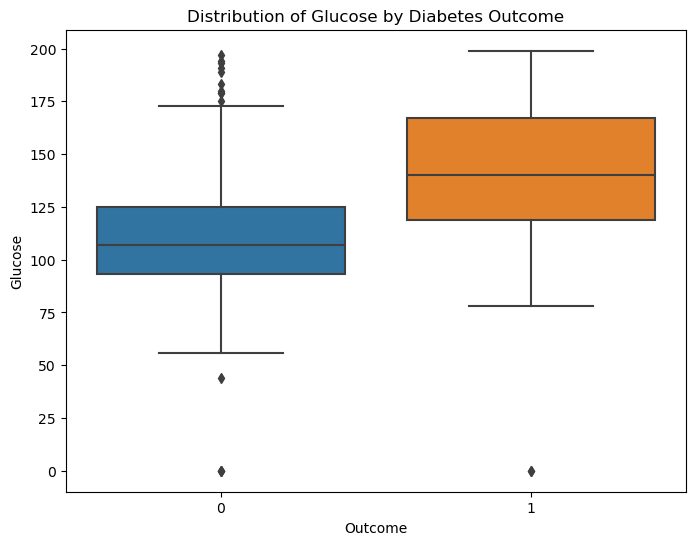

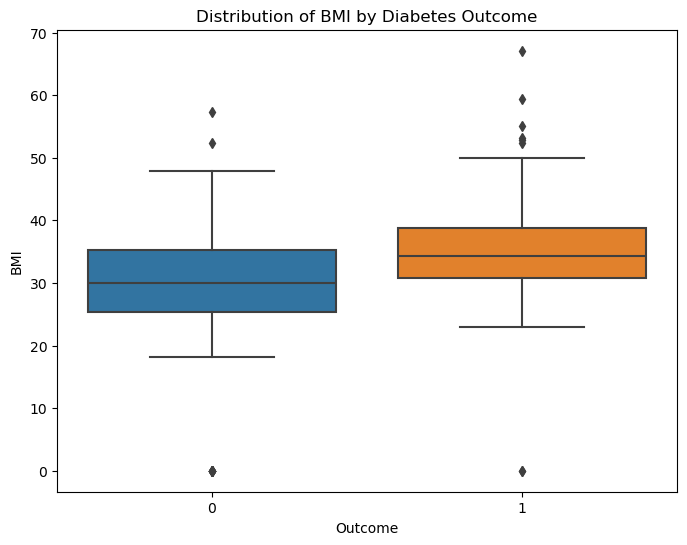

In [146]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="Outcome", y="Glucose", data=data)
plt.title("Distribution of Glucose by Diabetes Outcome")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x="Outcome", y="BMI", data=data)
plt.title("Distribution of BMI by Diabetes Outcome")
plt.show()

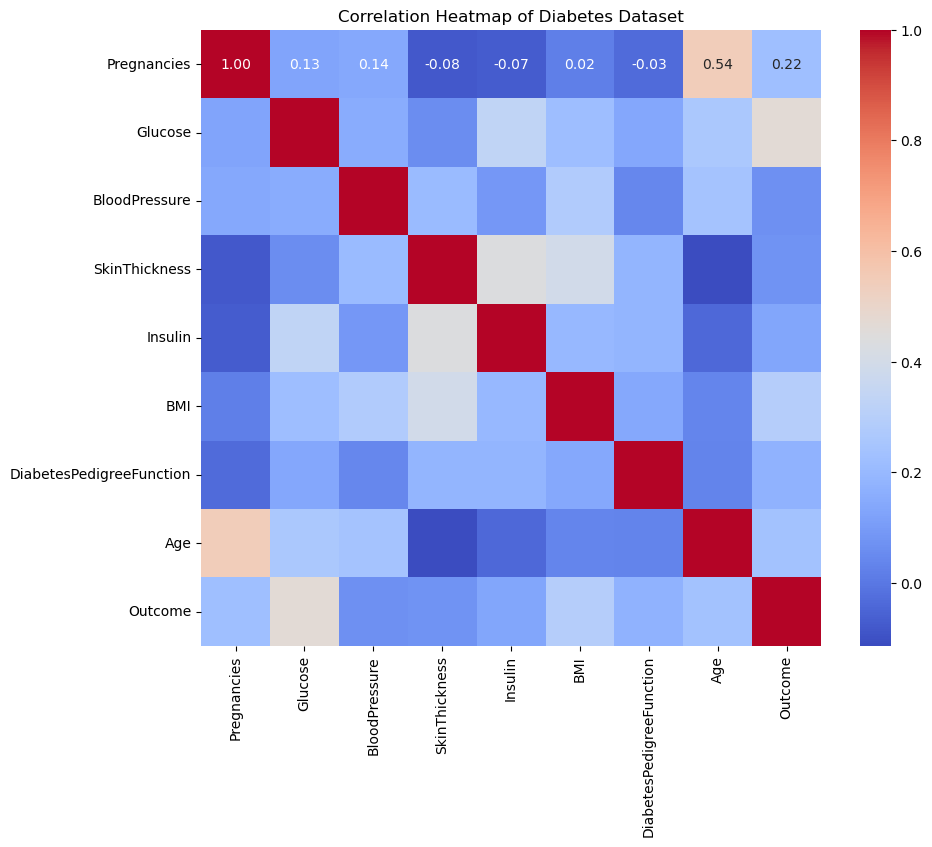

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()